In [ ]:
import earthquake_snr as earthquake
import os
import obspy
import util
import pickle
from multiprocessing import Pool
import setup_paths as paths
import matplotlib.pyplot as plt

# fill out this with the parameters you want to use
# window length, blank window, filename to use
parameters = [[0.3, 0, 'eq_object_03s_snr_20_blank_0'],
              [0.5, 0, 'eq_object_05s_snr_20_blank_0'],
              [1, 0, 'eq_object_1s_snr_20_blank_0'],
              [4, 0, 'eq_object_4s_snr_20_blank_0']]

root_path = '/home/earthquakes1/homes/Rebecca/phd/data/'#paths.data_path
count = 0


def find_with_data(wanted):
    """
    Find earthquakes with data and picks.

    Args:
        wanted (str): The name of the directory of interest.

    Returns:
        - eq_with_data (list): A list of earthquake names with data and picks.
        - cat_with_data (obspy.Catalog): An ObsPy Catalog object containing events with data and picks.
    """
    folder = root_path + wanted + '/'
    cat = obspy.read_events(root_path + wanted + '_catalog.xml')
    eq_with_data = []
    cat_with_data = obspy.Catalog()
    for event in cat:  # check earthquakes have data AND PICKS
        eq_name = util.catEventToFileName(event)
        if (os.path.isdir(folder + eq_name)
                and os.path.isdir(folder + eq_name + '/station_xml_files')
                and os.path.exists(folder + eq_name + '/picks.pkl')):
            eq_with_data.append(eq_name)
            cat_with_data.extend([event])
    return eq_with_data, cat_with_data


def build_list():
    """
    Build a list of earthquakes with data and picks.

    Returns:
        list_for_multi (list): A list of lists containing the earthquake name, event, folder, and parameters.
    """
    #wanted_list = paths.data_subfolders
    wanted_list = ['2005_2018_global_m5', '2018_2021_global_m5', '2019_global_m3']
    list_for_multi = []
    for wanted in wanted_list:
        eq_with_data, cat_with_data = find_with_data(wanted)
        for params in parameters:
            for eq_no in range(0, len(eq_with_data)):
                list_for_multi.append([eq_with_data[eq_no],
                                      cat_with_data[eq_no],
                                      root_path + wanted + '/',
                                      params])
    return list_for_multi



In [ ]:

snr_list = []
mag_list = []
list_for_multi = build_list()


0
1


AttributeError: 'Earthquake' object has no attribute 'data'

In [45]:
from importlib import reload
reload(earthquake)

<module 'earthquake_snr' from '/home/earthquakes1/homes/Rebecca/phd/seismo_det/code/earthquake_snr.py'>

In [ ]:
snr_list = []
mag_list = []
for i in range(0, 100):
	#print(i)
	eq_with_data_name, event, folder, params = list_for_multi[i]
	WINDOW_LEN, blank_window, fn = params
	#if os.path.isfile(folder + eq_with_data_name + '/' + fn + '_reviews_snr_20.pkl') is False:
	eq = earthquake.Earthquake(eq_with_data_name, event, root=folder)
	eq.eq_info()
	eq.calc_snr(root=folder)
	if eq.data is not False:
		#print('in if')
		#print(eq.snr)
		#print(eq.__dict__)
		snr_list.append(eq.snr)
		mag_list.append(eq.event_stats['eq_mag'])
		#print('snr_list', snr_list)
		#print('mag_list', mag_list)
	else:
		pass #print('no data')
	if i==10:
		print(i)
		with open('snr_list.pkl', 'wb') as f:
			pickle.dump(snr_list, f)
		with open('mag_list.pkl', 'wb') as f:
			pickle.dump(mag_list, f)
	elif i%10 == 0:
		print(i)
		with open('snr_list.pkl', 'ab') as f:
			pickle.dump(snr_list, f)
		with open('mag_list.pkl', 'ab') as f:
			pickle.dump(mag_list, f)


/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: snr 58.32085561497326
calc_snr: snr 52.537352555701176
calc_snr: snr 53.0727826675694
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
0
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate


/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sam

/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


...

calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no

/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: snr 14.732164449818622
calc_snr: snr 23.49932341001353
calc_snr: snr 36.59654320987654


/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "
/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc5/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1, ObsPy can read versions (1.0, 1.1, 1.2). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rate
calc_snr: no pick or wrong sampling rat

In [93]:
all_mags = []
all_snr = []
prop_removed = []

for i in range(0, len(snr_list)):
	above_20 = 0
	below_20 = 0
	no_pick = 0
	for snr in snr_list[i]:
		all_snr.append(snr)
		all_mags.append(mag_list[i])
		if snr == 1000000:
			no_pick += 1
		elif snr > 20:
			above_20 += 1
		else:
			below_20 += 1
	print(below_20/(above_20+below_20))
	prop_removed.append(below_20/(above_20+below_20))
	# print(above_20/(above_20+below_20+no_pick))
	# print(no_pick/(above_20+below_20+no_pick))

all_mags = np.array(all_mags)
all_snr = np.array(all_snr)

0.0
0.0
0.5
0.3333333333333333
0.0
0.2463768115942029
0.5384615384615384
0.0
0.6666666666666666
0.0
0.013071895424836602
0.8333333333333334
0.7971014492753623
0.23809523809523808
0.0
0.8333333333333334
0.0
0.06666666666666667
0.4
0.0
0.8333333333333334
0.3333333333333333


In [98]:
snr_from_file = []
mag_from_file = []

with open('snr_list.pkl', 'rb') as f:
	while True:
		try:
			snr_from_file.append(pickle.load(f))
		except EOFError:
			break

with open('mag_list.pkl', 'rb') as f:
	while True:
		try:
			mag_from_file.append(pickle.load(f))
		except EOFError:
			break

In [101]:
snr_from_file

[[[1000000,
   1000000,
   1000000,
   58.32085561497326,
   52.537352555701176,
   53.0727826675694,
   1000000,
   1000000,
   1000000]],
 [[1000000,
   1000000,
   1000000,
   58.32085561497326,
   52.537352555701176,
   53.0727826675694,
   1000000,
   1000000,
   1000000],
  [404.58788395904435,
   332.43465909090907,
   444.4058529072006,
   1000000,
   1000000,
   1000000],
  [6.091229838709677,
   5.996402877697841,
   9.909547738693467,
   37.120221948212084,
   35.78657378087397,
   20.13999353378597,
   1000000,
   1000000,
   1000000],
  [18.245489690721648,
   15.41569360112097,
   32.5345080763583,
   56.01108801108801,
   53.01470588235294,
   39.71699516548903,
   1000000,
   1000000,
   1000000]],
 [[1000000,
   1000000,
   1000000,
   58.32085561497326,
   52.537352555701176,
   53.0727826675694,
   1000000,
   1000000,
   1000000],
  [404.58788395904435,
   332.43465909090907,
   444.4058529072006,
   1000000,
   1000000,
   1000000],
  [6.091229838709677,
   5.99640

In [102]:
snr_list

[[1000000,
  1000000,
  1000000,
  58.32085561497326,
  52.537352555701176,
  53.0727826675694,
  1000000,
  1000000,
  1000000],
 [404.58788395904435,
  332.43465909090907,
  444.4058529072006,
  1000000,
  1000000,
  1000000],
 [6.091229838709677,
  5.996402877697841,
  9.909547738693467,
  37.120221948212084,
  35.78657378087397,
  20.13999353378597,
  1000000,
  1000000,
  1000000],
 [18.245489690721648,
  15.41569360112097,
  32.5345080763583,
  56.01108801108801,
  53.01470588235294,
  39.71699516548903,
  1000000,
  1000000,
  1000000],
 [2298.171171171171,
  4024.625,
  2952.6666666666665,
  4848.345864661655,
  5519.95,
  13043.245614035088,
  6398.617391304348,
  5100.297619047619,
  7171.259259259259,
  928.6298342541437,
  2085.7374301675977,
  938.2459893048128,
  1000000,
  1000000,
  1000000,
  3404.725490196078,
  11153.0,
  3336.153846153846,
  4231.7,
  2795.0481927710844,
  3112.55,
  1000000,
  1000000,
  1000000,
  1000000,
  1000000,
  1000000,
  615.3734939759037

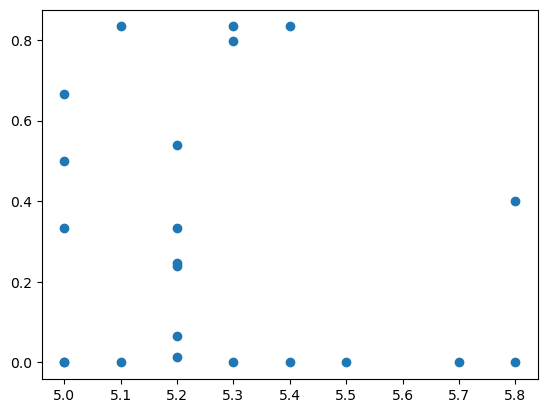

In [95]:
plt.scatter(mag_list, prop_removed)

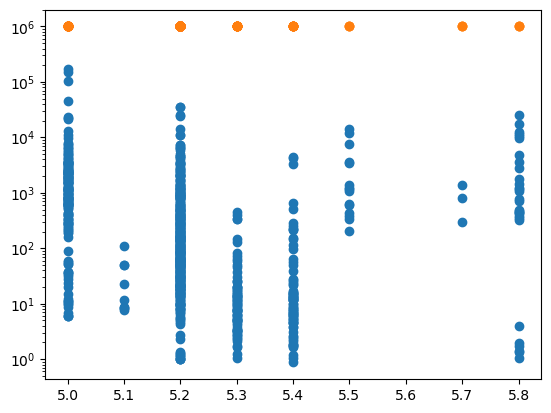

In [89]:
no_data = (np.where(np.array(all_snr) == 1000000))
mask = np.ones(len(all_snr), dtype=bool)
mask[no_data] = False
plt.scatter(all_mags[mask], all_snr[mask])
plt.scatter(all_mags[~mask], all_snr[~mask])
plt.yscale('log')